# Convex Optimization with CVXPY - Tutorial
This tutorial will introduce you to convex optimization using the CVXPY library in Python. We'll cover various types of optimization problems with practical examples and visualizations.

## 1. Introduction
- Convex optimization is a branch of mathematical optimization concerned with minimizing convex functions over convex sets. Many problems in machine learning, finance, engineering, and statistics can be formulated this way.

- CVXPY is a Python-embedded modeling language for convex optimization. It lets you express problems naturally and automatically translates them into the standard forms required by solvers.
  
## 2. Setting up the Environment
Let's start by importing the necessary libraries.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy as sp
import cvxpy as cp

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## 3. Basic Linear Programming
Let's start with a simple linear programming problem. We'll solve a resource allocation problem:

A company produces two products, A and B. The profit per unit is 3 HK dollar for A and 2 HK dollar for B. Production constraints:

- Product A requires 2 hours of machining and 1 hour of assembly
- Product B requires 1 hour of machining and 2 hours of assembly
- Available resources: 100 hours of machining, 80 hours of assembly
- Demand: Maximum 40 units of product A

Find the optimal production quantities to maximize profit.

$$
\begin{align*}
    \max \quad & 3 x_A + 2 x_B \\
    \text{s.t.} \quad & 2 x_A + x_B \leq 100, \\
    & x_A + 2 x_B \leq 80, \\
    & x_A \leq 40, \\
    & x_A \geq 0,\ x_B \geq 0.
\end{align*}
$$

Status: optimal
Optimal production: A = 40.00, B = 20.00
Maximum profit: $160.00


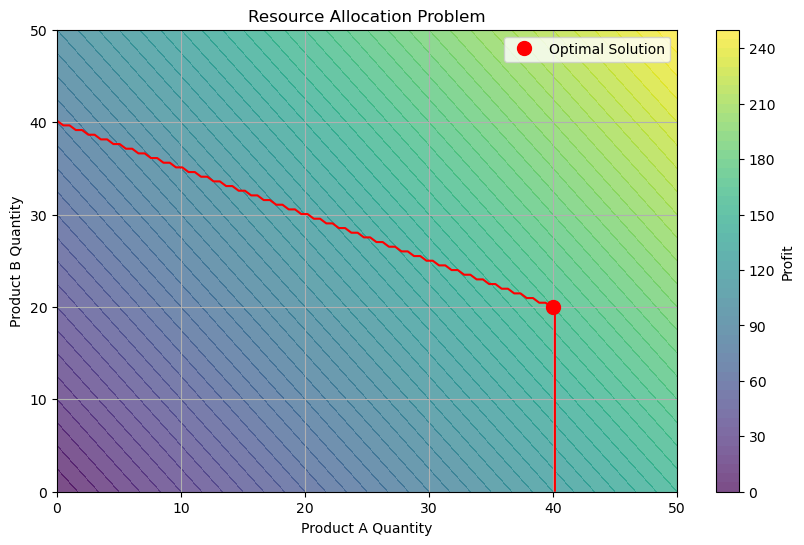

In [13]:
# Define variables
x = cp.Variable(2, integer=False)  # Quantity of products A and B

# Define parameters
profit = np.array([3, 2])  # Profit per unit for A and B
machining = np.array([2, 1])  # Machining hours per unit
assembly = np.array([1, 2])  # Assembly hours per unit

# Constraints
constraints = [
    machining @ x <= 100,  # Machining constraint
    assembly @ x <= 80,    # Assembly constraint
    x[0] <= 40,            # Demand constraint for A
    x >= 0                 # Non-negativity constraint
]

# Objective function
objective = cp.Maximize(profit @ x)

# Solve the problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Display results
print(f"Status: {problem.status}")
print(f"Optimal production: A = {x.value[0]:.2f}, B = {x.value[1]:.2f}")
print(f"Maximum profit: ${profit @ x.value:.2f}")

# Visualize the feasible region and solution
# Create a grid of points
a_vals = np.linspace(0, 50, 100)
b_vals = np.linspace(0, 50, 100)
A, B = np.meshgrid(a_vals, b_vals)

# Calculate constraints
machining_constraint = 2*A + B <= 100
assembly_constraint = A + 2*B <= 80
demand_constraint = A <= 40

# Combine constraints
feasible = machining_constraint & assembly_constraint & demand_constraint & (A >= 0) & (B >= 0)

# Calculate profit
Profit = 3*A + 2*B

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(A, B, Profit, 50, alpha=0.7, cmap='viridis')
plt.colorbar(label='Profit')
plt.contour(A, B, feasible, levels=[0.5], colors='red', linewidths=1.5)
plt.plot(x.value[0], x.value[1], 'ro', markersize=10, label='Optimal Solution')
plt.xlabel('Product A Quantity')
plt.ylabel('Product B Quantity')
plt.title('Resource Allocation Problem')
plt.legend()
plt.grid(True)
plt.show()

## 4. Quadratic Programming
Let's solve a quadratic programming problem. We'll work on a simple portfolio optimization problem that minimizes portfolio variance (risk) while achieving a target return:

$$
\begin{align*}
    \min_{w} \quad & w^\top \Sigma w \\
    \text{s.t.} \quad & \mu^\top w \geq r, \\
    & 1^\top w = 1, \\
    & w \geq 0.
\end{align*}
$$

Status: optimal
Optimal Weight of Asset 1: 0.2943
Optimal Weight of Asset 2: 0.1922
Optimal Weight of Asset 3: 0.1382
Optimal Weight of Asset 4: 0.2088
Optimal Weight of Asset 5: 0.1665
Expected return: 0.0210
Portfolio variance: 0.001776


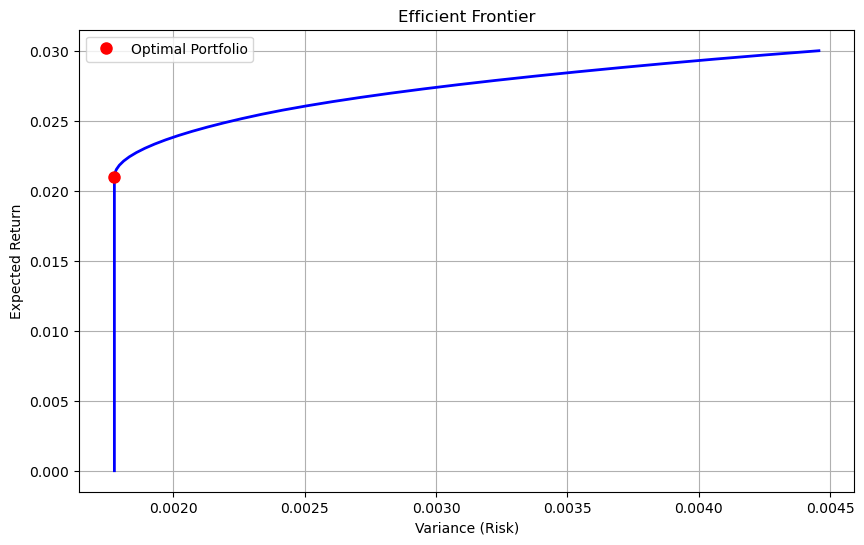

In [14]:
# Generate random returns for two assets
np.random.seed(42)
n_assets = 5
returns = np.random.randn(100, n_assets) * 0.1 + 0.02  # 100 days of returns

# Calculate expected returns and covariance matrix
mu = np.mean(returns, axis=0)
Sigma = np.cov(returns.T)

# Define the target return
target_return = 0.02

# Define variables
w = cp.Variable(n_assets)  # Portfolio weights

# Define objective: minimize variance (risk)
objective = cp.Minimize(cp.quad_form(w, Sigma))

# Constraints
constraints = [
    mu @ w >= target_return,  # Target return constraint
    cp.sum(w) == 1,           # Budget constraint (weights sum to 1)
    w >= 0                    # No short selling
]

# Solve the problem
problem = cp.Problem(objective, constraints)
problem.solve()

# Display results
print(f"Status: {problem.status}")
for i in range(n_assets):
    print(f"Optimal Weight of Asset {i+1}: {w.value[i]:.4f}")
print(f"Expected return: {mu @ w.value:.4f}")
print(f"Portfolio variance: {w.value @ Sigma @ w.value:.6f}")

# Visualize the efficient frontier
n_points = 100
target_returns = np.linspace(0, 0.03, n_points)
variances = np.zeros(n_points)

for i, ret in enumerate(target_returns):
    w_i = cp.Variable(n_assets)
    objective_i = cp.Minimize(cp.quad_form(w_i, Sigma))
    constraints_i = [
        mu @ w_i >= ret,
        cp.sum(w_i) == 1,
        w_i >= 0
    ]
    problem = cp.Problem(objective_i, constraints_i)
    problem.solve()
    variances[i] = problem.value

plt.figure(figsize=(10, 6))
plt.plot(variances, target_returns, 'b-', linewidth=2)
plt.plot(w.value @ Sigma @ w.value, mu @ w.value, 'ro', markersize=8, label='Optimal Portfolio')
plt.xlabel('Variance (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()

## 5. Lasso Regression
Let's solve a sparse signal recovery problem using L1 regularization:

$$
\begin{align*}
    \min_{x} \quad & \frac{1}{2} \| Ax - b \|^2 + \lambda \|x\|_1 \\
    \text{s.t.} \quad & x \geq 0.
\end{align*}
$$

Status: optimal
Recovery error: 0.5490
Non-zero elements: Original = 10, Recovered = 29


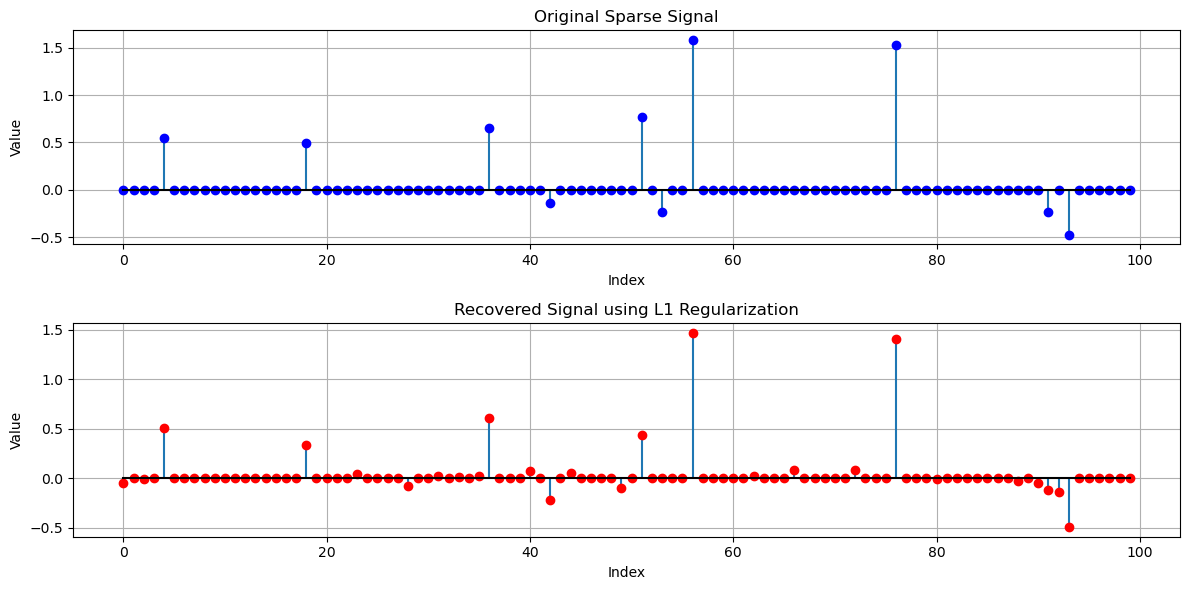

In [15]:
# Generate a sparse signal
np.random.seed(42)
n = 100  # Signal dimension
k = 10   # Number of non-zero elements
m = 30   # Number of measurements

# Create a sparse signal
x_true = np.zeros(n)
x_true[np.random.choice(n, k, replace=False)] = np.random.randn(k)

# Create measurement matrix
A = np.random.randn(m, n)

# Add noise
noise = 0.1 * np.random.randn(m)
b = A @ x_true + noise

# Solve the L1 regularized problem (LASSO)
x = cp.Variable(n)
lambda_param = cp.Parameter(nonneg=True)
lambda_param.value = 0.1

objective = cp.Minimize(0.5 * cp.sum_squares(A @ x - b) + lambda_param * cp.norm(x, 1))
problem = cp.Problem(objective)
problem.solve()

# Display results
print(f"Status: {problem.status}")
print(f"Recovery error: {np.linalg.norm(x.value - x_true):.4f}")

# Count non-zero elements
nonzero_original = np.sum(np.abs(x_true) > 1e-4)
nonzero_recovered = np.sum(np.abs(x.value) > 1e-4)
print(f"Non-zero elements: Original = {nonzero_original}, Recovered = {nonzero_recovered}")

# Visualize the results
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(range(n), x_true, markerfmt='bo', basefmt='k-')
plt.title('Original Sparse Signal')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.stem(range(n), x.value, markerfmt='ro', basefmt='k-')
plt.title('Recovered Signal using L1 Regularization')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Conclusion
CVXPY provides a powerful and intuitive way to formulate and solve convex optimization problems. Its strength lies in its ability to automatically transform problems into standard forms that solvers can handle efficiently.

Key Takeaways:
- CVXPY allows natural problem formulation
- It supports a wide range of convex optimization problems
- The library automatically handles problem transformations
- Various solvers can be used with CVXPY
- Visualization helps understand optimization results

Remember that while CVXPY is powerful for convex problems, it cannot handle non-convex optimization directly. For non-convex problems, you might need to consider other approaches or reformulate your problem to make it convex.

Further Learning:
- [CVXPY documentation](https://www.cvxpy.org/)
- [Convex Optimization in Quantitative Finance](https://web.stanford.edu/~boyd/papers/pdf/cvx-finance-slides.pdf)
- [Portfolio Optimization using Python and CVXPY](https://medium.com/the-modern-scientist/how-to-select-your-mpf-portfolio-wisely-portfolio-optimization-53c9b86621b2)